In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/primus11/cic-ids-2018-dataset/cic.csv


In [2]:
!pip install scikit-learn xgboost lightgbm joblib numpy pandas matplotlib seaborn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, joblib, time
warnings.filterwarnings('ignore')

from sklearn.svm import SVC, OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import (IsolationForest, RandomForestClassifier,
    GradientBoostingClassifier, VotingClassifier,
    BaggingClassifier, AdaBoostClassifier)
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TF = True
    print(f'TensorFlow {tf.__version__} ready')
except ImportError:
    HAS_TF = False
    print('TensorFlow not available — DNN will be skipped')

RANDOM = 42
np.random.seed(RANDOM)
plt.style.use('seaborn-v0_8-darkgrid')
PAL = ['#4f7cff','#22c55e','#f59e0b','#ef4444','#8b5cf6','#06b6d4','#ec4899','#14b8a6']
os.makedirs('models', exist_ok=True)
print('Imports ready.')

2026-05-02 10:56:18.590841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777719378.809824      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777719378.879747      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777719379.381352      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719379.381395      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777719379.381398      22 computation_placer.cc:177] computation placer alr

TensorFlow 2.19.0 ready
Imports ready.


In [3]:
# ── CIC-IDS 2018 has 80 columns + Label
# Kaggle path: /kaggle/input/<your-dataset-name>/cic.csv
CSV_PATH = '/kaggle/input/datasets/primus11/cic-ids-2018-dataset/cic.csv'   # adjust if slug differs

print(f'Loading {CSV_PATH} ...')
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns  : {list(df_raw.columns[:10])} ... ({len(df_raw.columns)} total)')
print(f'\nLabel distribution:')
print(df_raw['Label'].value_counts())
df_raw.head(3)

Loading /kaggle/input/datasets/primus11/cic-ids-2018-dataset/cic.csv ...
Raw shape: (1048575, 80)
Columns  : ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min'] ... (80 total)

Label distribution:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign


In [4]:
# ─────────────────────────────────────────────────────────
# CIC-IDS 2018 columns from the screenshot
# ─────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Dst Port','Protocol','Flow Duration',
    'Tot Fwd Pkts','Tot Bwd Pkts','TotLen Fwd Pkts','TotLen Bwd Pkts',
    'Fwd Pkt Len Max','Fwd Pkt Len Min','Fwd Pkt Len Mean','Fwd Pkt Len Std',
    'Bwd Pkt Len Max','Bwd Pkt Len Min','Bwd Pkt Len Mean','Bwd Pkt Len Std',
    'Flow Byts/s','Flow Pkts/s',
    'Flow IAT Mean','Flow IAT Std','Flow IAT Max','Flow IAT Min',
    'Fwd IAT Tot','Fwd IAT Mean','Fwd IAT Std','Fwd IAT Max','Fwd IAT Min',
    'Bwd IAT Tot','Bwd IAT Mean','Bwd IAT Std','Bwd IAT Max','Bwd IAT Min',
    'Fwd PSH Flags','Bwd PSH Flags','Fwd URG Flags','Bwd URG Flags',
    'Fwd Header Len','Bwd Header Len','Fwd Pkts/s','Bwd Pkts/s',
    'Pkt Len Min','Pkt Len Max','Pkt Len Mean','Pkt Len Std','Pkt Len Var',
    'FIN Flag Cnt','SYN Flag Cnt','RST Flag Cnt','PSH Flag Cnt',
    'ACK Flag Cnt','URG Flag Cnt','CWE Flag Count','ECE Flag Cnt',
    'Down/Up Ratio','Pkt Size Avg','Fwd Seg Size Avg','Bwd Seg Size Avg',
    'Fwd Byts/b Avg','Fwd Pkts/b Avg','Fwd Blk Rate Avg',
    'Bwd Byts/b Avg','Bwd Pkts/b Avg','Bwd Blk Rate Avg',
    'Subflow Fwd Pkts','Subflow Fwd Byts','Subflow Bwd Pkts','Subflow Bwd Byts',
    'Init Fwd Win Byts','Init Bwd Win Byts','Fwd Act Data Pkts','Fwd Seg Size Min',
    'Active Mean','Active Std','Active Max','Active Min',
    'Idle Mean','Idle Std','Idle Max','Idle Min',
]
LABEL_COL = 'Label'

# Keep only columns that actually exist in the CSV
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_raw.columns]
print(f'Features available: {len(FEATURE_COLS)} / 78')

df = df_raw[FEATURE_COLS + [LABEL_COL]].copy()

# ── Drop Timestamp if present (not numeric)
if 'Timestamp' in df.columns:
    df.drop(columns=['Timestamp'], inplace=True)

# ── Replace inf / -inf with NaN, then impute
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'NaN count before impute: {df[FEATURE_COLS].isnull().sum().sum()}')

imputer = SimpleImputer(strategy='median')
df[FEATURE_COLS] = imputer.fit_transform(df[FEATURE_COLS])
print(f'NaN count after impute : {df[FEATURE_COLS].isnull().sum().sum()}')

# ── Label encoding
print(f'\nRaw labels: {df[LABEL_COL].unique()}')

# Binary: Benign=0, any attack=1
df['label_binary'] = (df[LABEL_COL].str.strip() != 'Benign').astype(int)

# Multi-class: keep top N attack types, group rest as 'Other'
TOP_N = 8
top_labels = df[LABEL_COL].value_counts().nlargest(TOP_N).index.tolist()
df['label_multi_str'] = df[LABEL_COL].apply(
    lambda x: x.strip() if x.strip() in top_labels else 'Other')

le = LabelEncoder()
df['label_multi'] = le.fit_transform(df['label_multi_str'])

print(f'\nMulti-class distribution:')
print(df['label_multi_str'].value_counts())
print(f'\nDataset shape after cleaning: {df.shape}')

Features available: 78 / 78
NaN count before impute: 7648
NaN count after impute : 0

Raw labels: ['Benign' 'FTP-BruteForce' 'SSH-Bruteforce']

Multi-class distribution:
label_multi_str
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64

Dataset shape after cleaning: (1048575, 82)


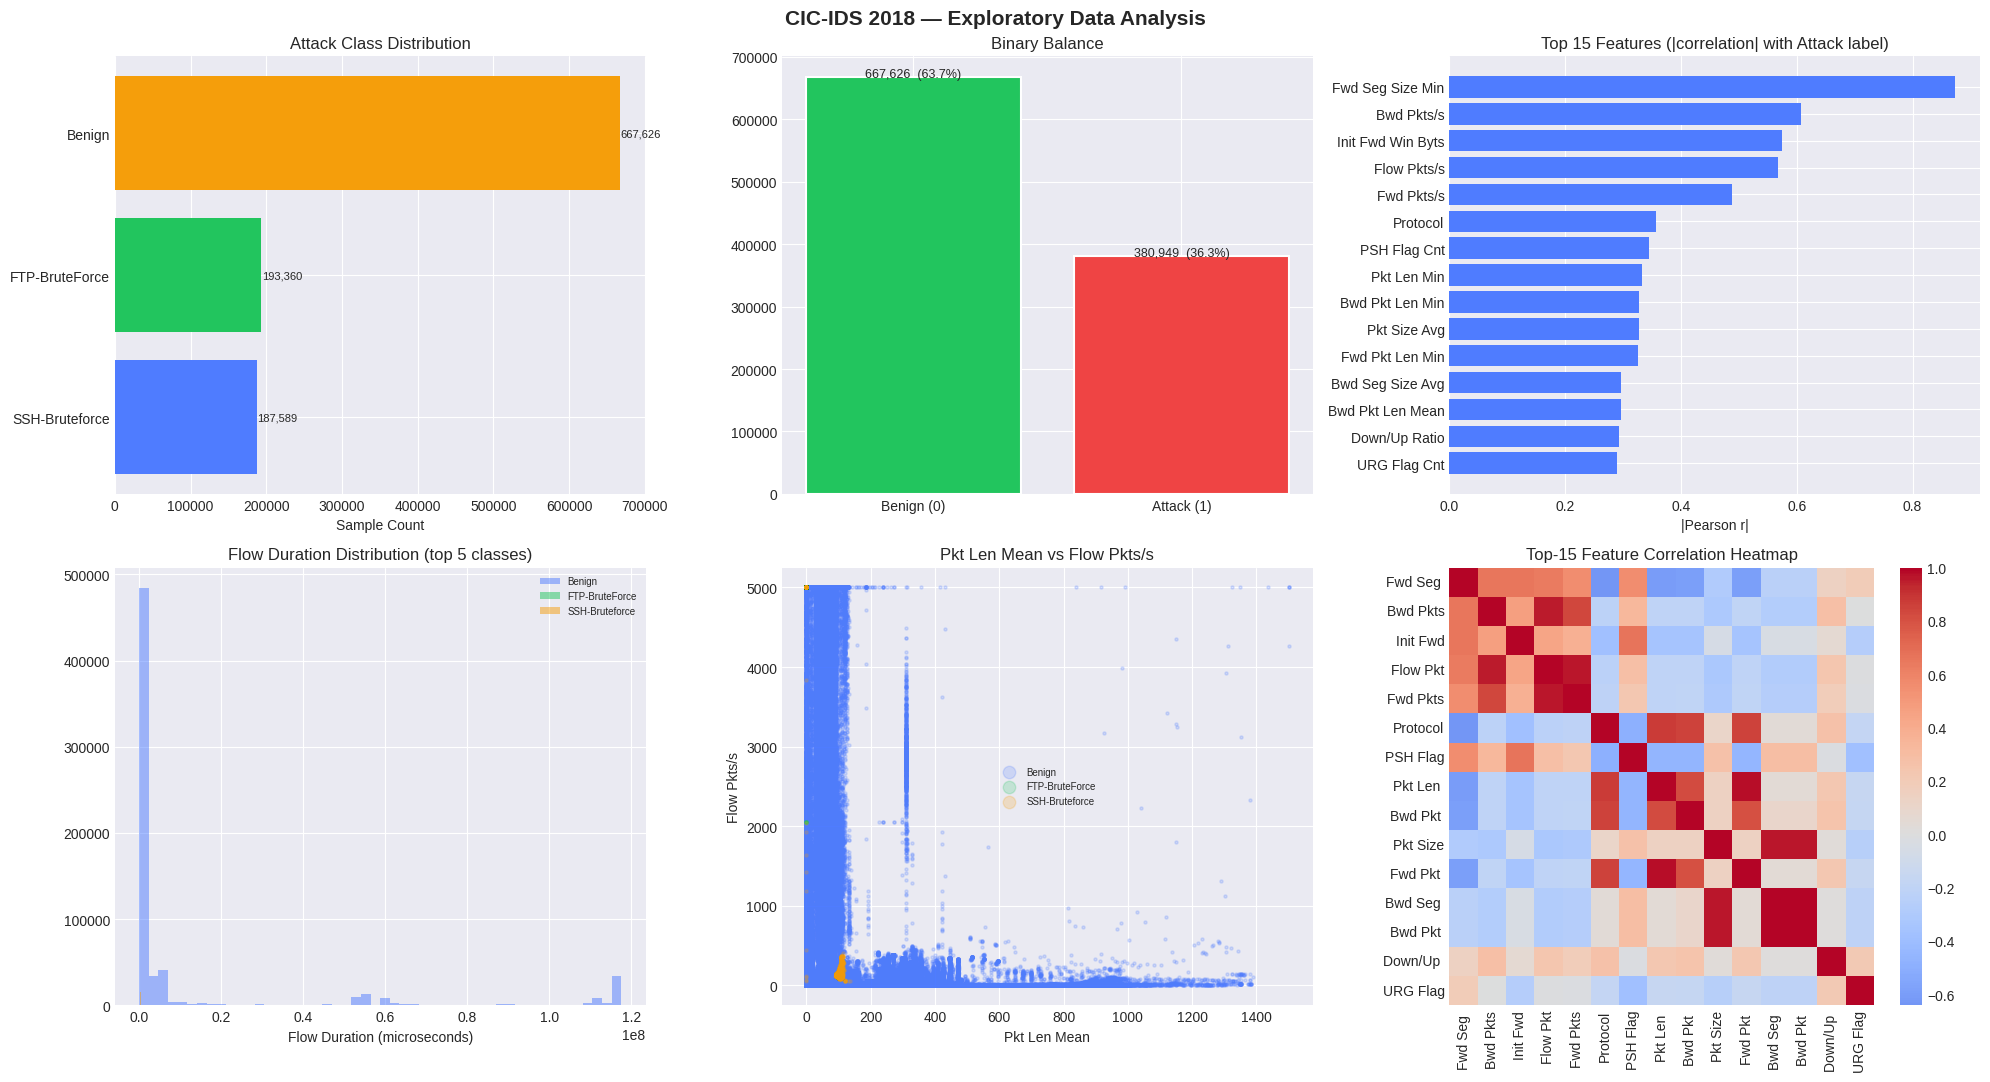

EDA saved to models/eda_cicids.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('CIC-IDS 2018 — Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Class distribution
vc = df['label_multi_str'].value_counts()
axes[0,0].barh(vc.index[::-1], vc.values[::-1],
               color=[PAL[i % len(PAL)] for i in range(len(vc))])
axes[0,0].set_title('Attack Class Distribution')
axes[0,0].set_xlabel('Sample Count')
for i, v in enumerate(vc.values[::-1]):
    axes[0,0].text(v + 500, i, f'{v:,}', va='center', fontsize=8)

# Binary balance
bin_vc = df['label_binary'].value_counts()
axes[0,1].bar(['Benign (0)', 'Attack (1)'], bin_vc.values,
               color=[PAL[1], PAL[3]], edgecolor='white', linewidth=1.5)
axes[0,1].set_title('Binary Balance')
for i, v in enumerate(bin_vc.values):
    pct = v / len(df) * 100
    label_str = f'{v:,}  ({pct:.1f}%)'
    axes[0,1].text(i, v + 500, label_str, ha='center', fontsize=9)

# Top 15 feature correlations with binary label
corr_bin = df[FEATURE_COLS].corrwith(df['label_binary']).abs().sort_values(ascending=False)
top15 = corr_bin.head(15)
axes[0,2].barh(top15.index[::-1], top15.values[::-1], color=PAL[0])
axes[0,2].set_title('Top 15 Features (|correlation| with Attack label)')
axes[0,2].set_xlabel('|Pearson r|')

# Flow Duration by class (top 5 classes)
top5 = df['label_multi_str'].value_counts().nlargest(5).index
for cls, col in zip(top5, PAL):
    mask = df['label_multi_str'] == cls
    data = df.loc[mask, 'Flow Duration'].clip(0, df['Flow Duration'].quantile(0.99))
    axes[1,0].hist(data, bins=50, alpha=0.5, label=cls, color=col)
axes[1,0].set_title('Flow Duration Distribution (top 5 classes)')
axes[1,0].set_xlabel('Flow Duration (microseconds)')
axes[1,0].legend(fontsize=7)

# Packet length vs flow rate scatter
for cls, col in zip(top5, PAL):
    mask = df['label_multi_str'] == cls
    axes[1,1].scatter(
        df.loc[mask, 'Pkt Len Mean'].clip(0, 1500),
        df.loc[mask, 'Flow Pkts/s'].clip(0, 5000),
        alpha=0.2, s=5, label=cls, color=col)
axes[1,1].set_title('Pkt Len Mean vs Flow Pkts/s')
axes[1,1].set_xlabel('Pkt Len Mean')
axes[1,1].set_ylabel('Flow Pkts/s')
axes[1,1].legend(markerscale=4, fontsize=7)

# Correlation heatmap (top 15 features)
top15_feats = corr_bin.head(15).index.tolist()
corr_mat = df[top15_feats].corr()
sns.heatmap(corr_mat, ax=axes[1,2], cmap='coolwarm', center=0,
            annot=False,
            xticklabels=[f[:8] for f in top15_feats],
            yticklabels=[f[:8] for f in top15_feats])
axes[1,2].set_title('Top-15 Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('models/eda_cicids.png', dpi=120, bbox_inches='tight')
plt.show()
print('EDA saved to models/eda_cicids.png')

In [6]:
# CIC-IDS 2018 is heavily imbalanced (64% Benign).
# We use stratified sampling to keep it manageable on Kaggle CPU.
# Adjust SAMPLE_SIZE based on your Kaggle RAM (16GB → use 500_000).

SAMPLE_SIZE = 300_000   # total rows to work with

# Stratified sample per class
df_sampled = df.groupby('label_multi_str', group_keys=False).apply(
    lambda g: g.sample(min(len(g), int(SAMPLE_SIZE * len(g) / len(df))),
                       random_state=RANDOM)
).reset_index(drop=True)

print(f'Original dataset : {len(df):,} rows')
print(f'Sampled dataset  : {len(df_sampled):,} rows')
print(f'\nSampled class distribution:')
print(df_sampled['label_multi_str'].value_counts())

X_all      = df_sampled[FEATURE_COLS].values
y_bin_all  = df_sampled['label_binary'].values
y_multi_all= df_sampled['label_multi'].values

# Re-fit label encoder on sampled data labels
le_sample = LabelEncoder()
y_multi_all = le_sample.fit_transform(df_sampled['label_multi_str'])
CLASS_NAMES  = list(le_sample.classes_)
N_CLASSES    = len(CLASS_NAMES)

print(f'\nClasses ({N_CLASSES}): {CLASS_NAMES}')

Original dataset : 1,048,575 rows
Sampled dataset  : 299,998 rows

Sampled class distribution:
label_multi_str
Benign            191009
FTP-BruteForce     55320
SSH-Bruteforce     53669
Name: count, dtype: int64

Classes (3): ['Benign', 'FTP-BruteForce', 'SSH-Bruteforce']


In [7]:
# RobustScaler is better than StandardScaler for network data
# (outliers from attack traffic won't distort the scaling)
X_tr, X_te, y_tr_b, y_te_b = train_test_split(
    X_all, y_bin_all, test_size=0.2, random_state=RANDOM, stratify=y_bin_all)
_, _, y_tr_m, y_te_m = train_test_split(
    X_all, y_multi_all, test_size=0.2, random_state=RANDOM, stratify=y_multi_all)

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc = scaler.transform(X_te)

print(f'Train  : {X_tr.shape[0]:,} samples')
print(f'Test   : {X_te.shape[0]:,} samples')
print(f'Features: {X_tr.shape[1]}')
print(f'\nBinary train labels: {dict(zip(*np.unique(y_tr_b, return_counts=True)))}')
print(f'Multi  train labels: {dict(zip(*np.unique(y_tr_m, return_counts=True)))}')

joblib.dump(scaler,    'models/v2_scaler.pkl')
joblib.dump(imputer,   'models/v2_imputer.pkl')
with open('models/v2_feature_names.json','w') as f: json.dump(FEATURE_COLS, f)
with open('models/v2_label_classes.json','w') as f: json.dump(CLASS_NAMES, f)
print('\nScaler, imputer, metadata saved.')

Train  : 239,998 samples
Test   : 60,000 samples
Features: 78

Binary train labels: {np.int64(0): np.int64(152807), np.int64(1): np.int64(87191)}
Multi  train labels: {np.int64(0): np.int64(152807), np.int64(1): np.int64(44256), np.int64(2): np.int64(42935)}

Scaler, imputer, metadata saved.


In [8]:
# Train only on BENIGN traffic → detect anything that deviates
X_benign_sc = X_tr_sc[y_tr_b == 0]
print(f'Training anomaly models on {len(X_benign_sc):,} benign samples...')

# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=0.05,
                      max_samples=min(10000,len(X_benign_sc)),
                      random_state=RANDOM, n_jobs=-1)
iso.fit(X_benign_sc)
iso_preds = (iso.predict(X_te_sc) == -1).astype(int)
iso_det   = iso_preds[y_te_b==1].mean()
iso_fp    = iso_preds[y_te_b==0].mean()
print(f'IsolationForest | Detection rate: {iso_det:.4f} | FP rate: {iso_fp:.4f}')
joblib.dump(iso, 'models/v2_isoforest.pkl')

# One-Class SVM (subsample for speed)
n_oc = min(20000, len(X_benign_sc))
oc_svm = OneClassSVM(kernel='rbf', nu=0.05, gamma='scale')
oc_svm.fit(X_benign_sc[:n_oc])
oc_preds = (oc_svm.predict(X_te_sc) == -1).astype(int)
oc_det   = oc_preds[y_te_b==1].mean()
oc_fp    = oc_preds[y_te_b==0].mean()
print(f'One-Class SVM   | Detection rate: {oc_det:.4f} | FP rate: {oc_fp:.4f}')
joblib.dump(oc_svm, 'models/v2_ocsvm.pkl')
print('Anomaly models saved.')

Training anomaly models on 152,807 benign samples...
IsolationForest | Detection rate: 0.1696 | FP rate: 0.0491
One-Class SVM   | Detection rate: 0.0000 | FP rate: 0.0484
Anomaly models saved.


In [9]:
# SVM on subsample for speed (SVM is O(n^2) so cap at 50k)
N_SVM = min(10000, len(X_tr))
idx   = np.random.choice(len(X_tr), N_SVM, replace=False)
Xs_sub  = X_tr_sc[idx]
yb_sub  = y_tr_b[idx]

print(f'Training Binary SVM on {N_SVM:,} samples...')
t0 = time.time()
svm_bin = Pipeline([
    ('svc', SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=RANDOM, cache_size=2000))
])
svm_bin.fit(Xs_sub, yb_sub)
elapsed = time.time()-t0
y_pred_svm = svm_bin.predict(X_te_sc)
svm_acc  = accuracy_score(y_te_b, y_pred_svm)
svm_f1   = f1_score(y_te_b, y_pred_svm, average='weighted')
svm_auc  = roc_auc_score(y_te_b, svm_bin.predict_proba(X_te_sc)[:,1])
print(f'Binary SVM | Acc: {svm_acc:.4f} | F1: {svm_f1:.4f} | AUC: {svm_auc:.4f} | Time: {elapsed:.1f}s')
joblib.dump(svm_bin, 'models/v2_svm.pkl')
print('SVM saved.')

Training Binary SVM on 10,000 samples...
Binary SVM | Acc: 0.6367 | F1: 0.4954 | AUC: 0.9830 | Time: 32.9s
SVM saved.


Decision Tree  | Acc: 0.6341 | F1: 0.4966
                precision    recall  f1-score   support

        Benign       0.64      0.99      0.78     38202
FTP-BruteForce       0.19      0.00      0.01     11064
SSH-Bruteforce       0.19      0.00      0.01     10734

      accuracy                           0.63     60000
     macro avg       0.34      0.33      0.26     60000
  weighted avg       0.47      0.63      0.50     60000

Training Random Forest...
Random Forest  | Acc: 0.3850 | F1: 0.4121


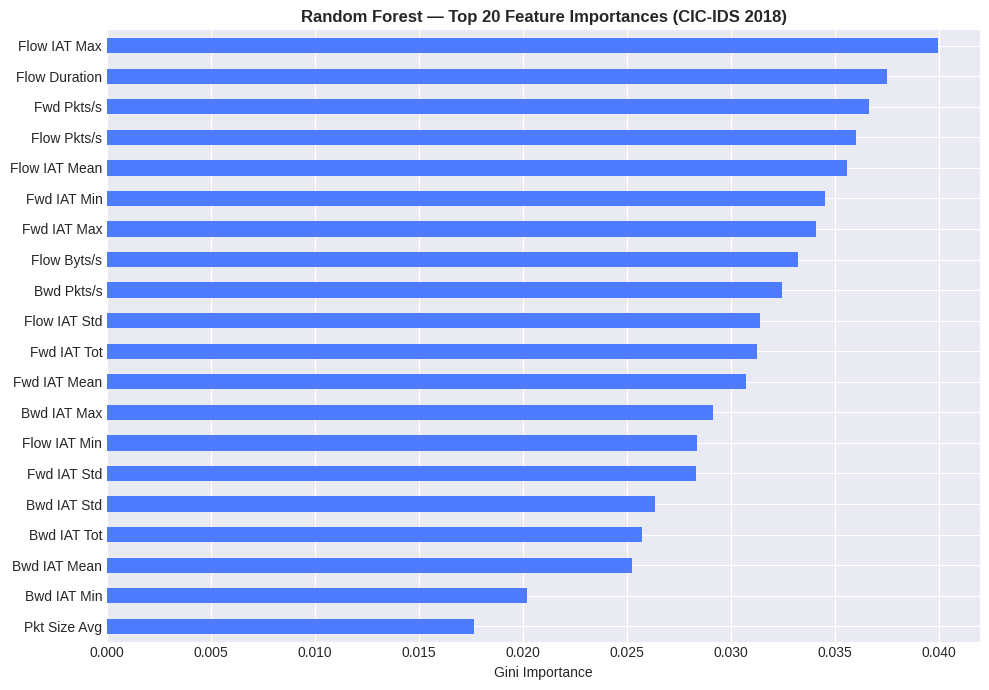

Top-5 features: ['Flow IAT Max', 'Flow Duration', 'Fwd Pkts/s', 'Flow Pkts/s', 'Flow IAT Mean']
DT + RF saved.


In [10]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=15, criterion='gini',
                             min_samples_leaf=10, random_state=RANDOM)
dt.fit(X_tr, y_tr_m)
dt_acc = accuracy_score(y_te_m, dt.predict(X_te))
dt_f1  = f1_score(y_te_m, dt.predict(X_te), average='weighted')
print(f'Decision Tree  | Acc: {dt_acc:.4f} | F1: {dt_f1:.4f}')
print(classification_report(y_te_m, dt.predict(X_te), target_names=CLASS_NAMES, zero_division=0))
joblib.dump(dt, 'models/v2_dt.pkl')

# Random Forest
print('Training Random Forest...')
rf = RandomForestClassifier(n_estimators=200, max_depth=20,
                             min_samples_leaf=5, random_state=RANDOM,
                             n_jobs=-1, class_weight='balanced')
rf.fit(X_tr, y_tr_m)
rf_acc = accuracy_score(y_te_m, rf.predict(X_te))
rf_f1  = f1_score(y_te_m, rf.predict(X_te), average='weighted')
print(f'Random Forest  | Acc: {rf_acc:.4f} | F1: {rf_f1:.4f}')
joblib.dump(rf, 'models/v2_rf.pkl')

# Feature importance
fi = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 7))
fi.head(20)[::-1].plot.barh(ax=ax, color=PAL[0])
ax.set_title('Random Forest — Top 20 Feature Importances (CIC-IDS 2018)', fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout(); plt.savefig('models/rf_importance.png', dpi=120); plt.show()
print(f'Top-5 features: {list(fi.head(5).index)}')
print('DT + RF saved.')

In [11]:
gnb = GaussianNB()
gnb.fit(X_tr_sc, y_tr_m)
gnb_acc = accuracy_score(y_te_m, gnb.predict(X_te_sc))
gnb_f1  = f1_score(y_te_m, gnb.predict(X_te_sc), average='weighted')
print(f'Gaussian NB    | Acc: {gnb_acc:.4f} | F1: {gnb_f1:.4f}')
print(classification_report(y_te_m, gnb.predict(X_te_sc),
      target_names=CLASS_NAMES, zero_division=0))
joblib.dump(gnb, 'models/v2_gnb.pkl')
print('Gaussian NB saved.')

Gaussian NB    | Acc: 0.1885 | F1: 0.0837
                precision    recall  f1-score   support

        Benign       0.64      0.02      0.04     38202
FTP-BruteForce       0.16      0.01      0.02     11064
SSH-Bruteforce       0.18      0.97      0.30     10734

      accuracy                           0.19     60000
     macro avg       0.33      0.33      0.12     60000
  weighted avg       0.47      0.19      0.08     60000

Gaussian NB saved.


In [12]:
class ELMClassifier:
    def __init__(self, n_hidden=2000, activation='relu', random_state=42):
        self.n_hidden=n_hidden; self.activation=activation
        self.random_state=random_state

    def _activate(self, X):
        if self.activation=='relu':    return np.maximum(0, X)
        if self.activation=='sigmoid': return 1/(1+np.exp(-np.clip(X,-500,500)))
        if self.activation=='tanh':    return np.tanh(X)
        return X

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.W = rng.randn(X.shape[1], self.n_hidden) * np.sqrt(2/X.shape[1])
        self.b = rng.randn(self.n_hidden) * 0.1
        self.classes_ = np.unique(y)
        Y = np.eye(len(self.classes_))[np.searchsorted(self.classes_, y)]
        H = self._activate(X @ self.W + self.b)
        lam = 1e-4   # ridge regularisation
        self.beta = np.linalg.solve(H.T@H + lam*np.eye(self.n_hidden), H.T@Y)
        return self

    def predict_proba(self, X):
        H = self._activate(X @ self.W + self.b)
        s = H @ self.beta
        e = np.exp(s - s.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

print('Training ELM...')
t0 = time.time()
elm = ELMClassifier(n_hidden=2000, activation='relu', random_state=RANDOM)
elm.fit(X_tr_sc, y_tr_m)
elm_time = time.time()-t0
elm_acc = accuracy_score(y_te_m, elm.predict(X_te_sc))
elm_f1  = f1_score(y_te_m, elm.predict(X_te_sc), average='weighted')
print(f'ELM | Acc: {elm_acc:.4f} | F1: {elm_f1:.4f} | Train time: {elm_time:.2f}s')
joblib.dump(elm, 'models/v2_elm.pkl')
print('ELM saved.')

Training ELM...
ELM | Acc: 0.6299 | F1: 0.4980 | Train time: 14.03s
ELM saved.


In [13]:
# Gradient Boosting
print('Training GradientBoosting (3-5 min)...')
t0 = time.time() 
gbc = GradientBoostingClassifier(n_estimators=150, max_depth=6,
                                  learning_rate=0.1, subsample=0.8,
                                  random_state=RANDOM)
gbc.fit(X_tr, y_tr_m)
gbc_acc = accuracy_score(y_te_m, gbc.predict(X_te))
gbc_f1  = f1_score(y_te_m, gbc.predict(X_te), average='weighted')
print(f'GradBoost     | Acc: {gbc_acc:.4f} | F1: {gbc_f1:.4f} | Time: {time.time()-t0:.1f}s')
joblib.dump(gbc, 'models/v2_gbc.pkl')

# Soft Voting Ensemble
print('Training Voting Ensemble...')
voter = VotingClassifier(estimators=[
    ('rf',  RandomForestClassifier(n_estimators=100, random_state=RANDOM, n_jobs=-1)),
    ('dt',  DecisionTreeClassifier(max_depth=12, random_state=RANDOM)),
    ('gnb', GaussianNB()), 
], voting='soft', n_jobs=-1)
voter.fit(X_tr_sc, y_tr_m)
voter_acc = accuracy_score(y_te_m, voter.predict(X_te_sc))
voter_f1  = f1_score(y_te_m, voter.predict(X_te_sc), average='weighted')
print(f'VotingEnsemble| Acc: {voter_acc:.4f} | F1: {voter_f1:.4f}')
joblib.dump(voter, 'models/v2_voting.pkl')

# AdaBoost
print('Training AdaBoost...')
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                          n_estimators=100, random_state=RANDOM)
ada.fit(X_tr, y_tr_m)
ada_acc = accuracy_score(y_te_m, ada.predict(X_te))
ada_f1  = f1_score(y_te_m, ada.predict(X_te), average='weighted')
print(f'AdaBoost      | Acc: {ada_acc:.4f} | F1: {ada_f1:.4f}')
joblib.dump(ada, 'models/v2_ada.pkl')

# Bagging
print('Training Bagging...')
bag = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=10),
                         n_estimators=20, random_state=RANDOM, n_jobs=-1)
bag.fit(X_tr, y_tr_m)
bag_acc = accuracy_score(y_te_m, bag.predict(X_te))
bag_f1  = f1_score(y_te_m, bag.predict(X_te), average='weighted')
print(f'Bagging       | Acc: {bag_acc:.4f} | F1: {bag_f1:.4f}')
joblib.dump(bag, 'models/v2_bagging.pkl')
print('All ensemble models saved.')

Training GradientBoosting (3-5 min)...
GradBoost     | Acc: 0.6362 | F1: 0.4956 | Time: 1566.6s
Training Voting Ensemble...
VotingEnsemble| Acc: 0.3214 | F1: 0.3176
Training AdaBoost...
AdaBoost      | Acc: 0.6366 | F1: 0.4954
Training Bagging...
Bagging       | Acc: 0.6366 | F1: 0.4954
All ensemble models saved.


I0000 00:00:1777721844.690277      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777721844.696313      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "protector_dnn_cicids"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,707 (846.51 KB)

 Trainable params: 214,915 (839.51 KB)

...

Epoch 1/60


I0000 00:00:1777721848.766864     165 service.cc:152] XLA service 0x7b4720002ea0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777721848.766899     165 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777721848.766903     165 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777721849.309005     165 cuda_dnn.cc:529] Loaded cuDNN version 91002


 50/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5085 - loss: 1.1448

I0000 00:00:1777721853.205516     165 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


399/399 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6000 - loss: 1.0021 - val_accuracy: 0.6364 - val_loss: 0.9096 - learning_rate: 0.0010
Epoch 2/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6352 - loss: 0.9168 - val_accuracy: 0.6366 - val_loss: 0.9128 - learning_rate: 0.0010
Epoch 3/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6345 - loss: 0.9151 - val_accuracy: 0.6366 - val_loss: 0.9081 - learning_rate: 0.0010
Epoch 4/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6350 - loss: 0.9124 - val_accuracy: 0.6366 - val_loss: 0.9081 - learning_rate: 0.0010
Epoch 5/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6369 - loss: 0.9088 - val_accuracy: 0.6366 - val_loss: 0.9079 - learning_rate: 0.0010
Epoch 6/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6364 - loss: 0.9094 - val_accuracy: 0.6366 - val_loss: 0.9078 - learning_rate: 0.0010
Epoch 7/60
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6369 - loss: 0.9085 - val_accur

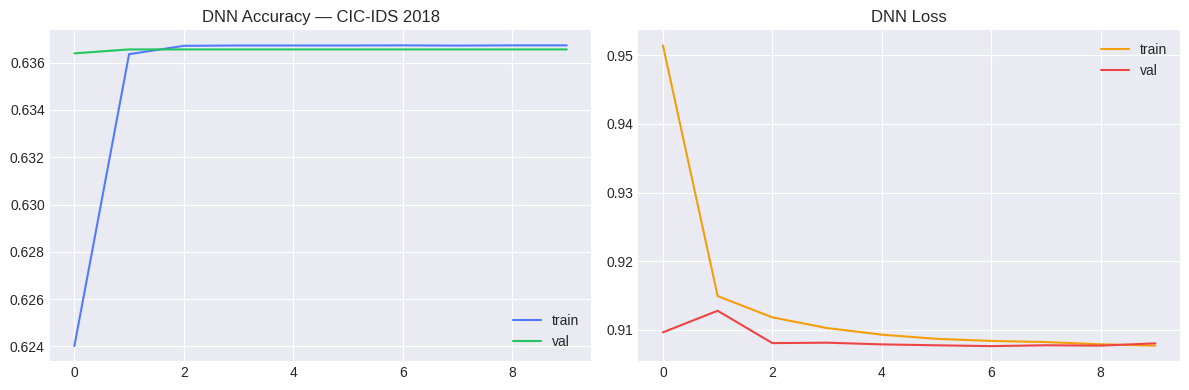

DNN saved.


In [14]:
if HAS_TF:
    n_cls   = len(CLASS_NAMES)
    inp_dim = len(FEATURE_COLS)

    def build_dnn(inp, n_cls):
        model = keras.Sequential([
            layers.Input(shape=(inp,)),
            layers.Dense(512, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.4),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(64,  activation='relu'),
            layers.Dropout(0.1),
            layers.Dense(n_cls, activation='softmax'),
        ], name='protector_dnn_cicids')
        model.compile(optimizer=keras.optimizers.Adam(1e-3),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

    dnn = build_dnn(inp_dim, n_cls)
    dnn.summary()

    cb = [
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True,
                                       monitor='val_accuracy'),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, verbose=1),
        keras.callbacks.ModelCheckpoint('models/v2_dnn_best.keras',
                                         save_best_only=True, monitor='val_accuracy'),
    ]

    hist = dnn.fit(X_tr_sc, y_tr_m, epochs=60, batch_size=512,
                   validation_split=0.15, callbacks=cb, verbose=1)

    dnn_acc = dnn.evaluate(X_te_sc, y_te_m, verbose=0)[1]
    dnn_f1  = f1_score(y_te_m,
                        np.argmax(dnn.predict(X_te_sc, verbose=0), axis=1),
                        average='weighted')
    print(f'DNN | Acc: {dnn_acc:.4f} | F1: {dnn_f1:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history['accuracy'],    label='train', color=PAL[0])
    axes[0].plot(hist.history['val_accuracy'], label='val',  color=PAL[1])
    axes[0].set_title('DNN Accuracy — CIC-IDS 2018')
    axes[0].legend()
    axes[1].plot(hist.history['loss'],    label='train', color=PAL[2])
    axes[1].plot(hist.history['val_loss'], label='val',  color=PAL[3])
    axes[1].set_title('DNN Loss')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig('models/dnn_training.png', dpi=120)
    plt.show()
    dnn.save('models/v2_dnn.keras')
    print('DNN saved.')
else:
    dnn_acc = 0.0; dnn_f1 = 0.0
    print('TensorFlow not available — enable GPU runtime on Kaggle.')

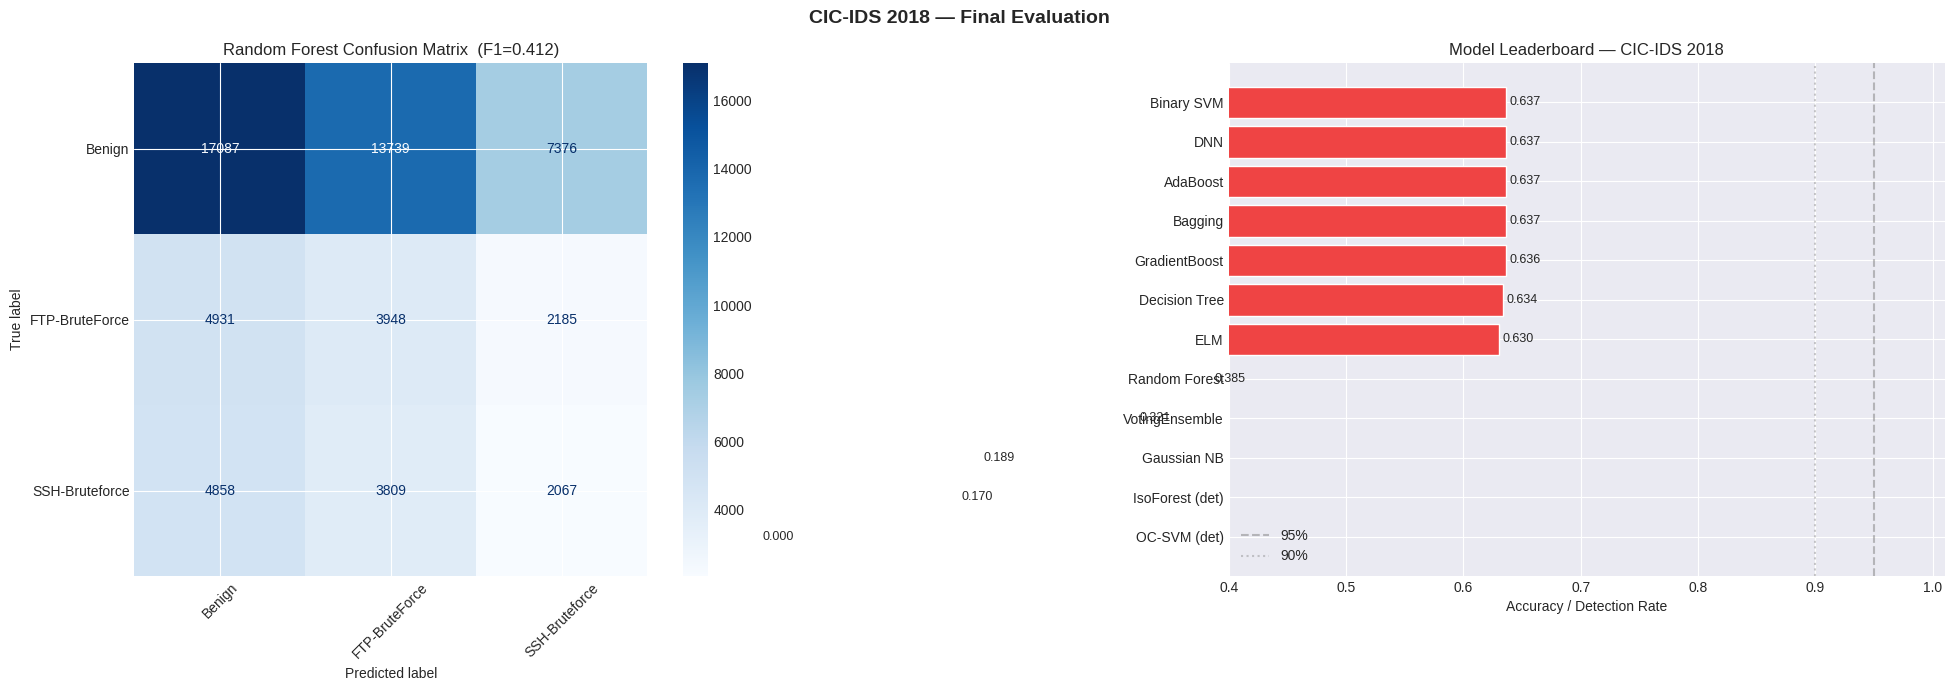


=== FINAL LEADERBOARD ===
                    score
Binary SVM       0.636700
DNN              0.636700
AdaBoost         0.636600
Bagging          0.636600
GradientBoost    0.636183
Decision Tree    0.634067
ELM              0.629933
Random Forest    0.385033
VotingEnsemble   0.321383
Gaussian NB      0.188533
IsoForest (det)  0.169603
OC-SVM (det)     0.000000

Manifest saved to models/v2_manifest.json
ZIP the models/ folder from Kaggle Output tab.
Download and extract to your i3 machine under protecter_v2/models/


In [15]:
# Confusion matrix for best model (Random Forest)
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('CIC-IDS 2018 — Final Evaluation', fontsize=14, fontweight='bold')

cm   = confusion_matrix(y_te_m, rf.predict(X_te))
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[0].set_title(f'Random Forest Confusion Matrix  (F1={rf_f1:.3f})')

# Leaderboard
results = {
    'IsoForest (det)' : iso_det,
    'OC-SVM (det)'    : oc_det,
    'Binary SVM'      : svm_acc,
    'Decision Tree'   : dt_acc,
    'Random Forest'   : rf_acc,
    'Gaussian NB'     : gnb_acc,
    'ELM'             : elm_acc,
    'GradientBoost'   : gbc_acc,
    'VotingEnsemble'  : voter_acc,
    'AdaBoost'        : ada_acc,
    'Bagging'         : bag_acc,
}
if HAS_TF: results['DNN'] = dnn_acc

df_res = pd.DataFrame({'score': results}).sort_values('score', ascending=False)
colors = ['#4f7cff' if v>0.95 else '#22c55e' if v>0.90 else
          '#f59e0b' if v>0.80 else '#ef4444' for v in df_res['score']]
axes[1].barh(df_res.index[::-1], df_res['score'].values[::-1],
             color=colors[::-1], edgecolor='white')
axes[1].axvline(0.95, color='gray', linestyle='--', alpha=0.5, label='95%')
axes[1].axvline(0.90, color='gray', linestyle=':',  alpha=0.4, label='90%')
axes[1].set_xlabel('Accuracy / Detection Rate')
axes[1].set_title('Model Leaderboard — CIC-IDS 2018')
axes[1].set_xlim(0.4, 1.01)
axes[1].legend()
for i, v in enumerate(df_res['score'].values[::-1]):
    axes[1].text(v+0.003, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('models/leaderboard.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== FINAL LEADERBOARD ===')
print(df_res.to_string())

# Save manifest
manifest = {
    'version'    : '2.0',
    'dataset'    : 'CIC-IDS-2018',
    'n_features' : len(FEATURE_COLS),
    'features'   : FEATURE_COLS,
    'classes'    : CLASS_NAMES,
    'n_classes'  : len(CLASS_NAMES),
    'sample_size': int(len(df_sampled)),
    'models'     : {
        'scaler'          : 'v2_scaler.pkl',
        'imputer'         : 'v2_imputer.pkl',
        'anomaly_iso'     : 'v2_isoforest.pkl',
        'anomaly_ocsvm'   : 'v2_ocsvm.pkl',
        'binary_svm'      : 'v2_svm.pkl',
        'multiclass_dt'   : 'v2_dt.pkl',
        'multiclass_rf'   : 'v2_rf.pkl',
        'multiclass_gnb'  : 'v2_gnb.pkl',
        'multiclass_elm'  : 'v2_elm.pkl',
        'ensemble_gbc'    : 'v2_gbc.pkl',
        'ensemble_voting' : 'v2_voting.pkl',
        'ensemble_ada'    : 'v2_ada.pkl',
        'ensemble_bagging': 'v2_bagging.pkl',
    },
    'leaderboard': results
}
if HAS_TF: manifest['models']['dnn'] = 'v2_dnn.keras'

with open('models/v2_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('\nManifest saved to models/v2_manifest.json')
print('ZIP the models/ folder from Kaggle Output tab.')
print('Download and extract to your i3 machine under protecter_v2/models/')